# Mutual Fund Performance Analytics

## Objective

This notebook computes key performance metrics for mutual funds, including:

- Daily Returns
- CAGR (1 Year, 3 Year, 5 Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Fund Scorecard
- Benchmark Comparison

Author: Om Dhavade

---
# Section 1 : Import Libraries
---

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

---
# Section 2 : Load Data
---

In [3]:
import os

print(os.getcwd())

C:\Users\OM DHAVADE\OneDrive\Desktop\MutualFundAnalytics\notebooks


In [4]:
import os

print(os.listdir(".."))

['.git', '.ipynb_checkpoints', 'charts', 'clean_investor_transactions.py', 'clean_nav_history.py', 'clean_scheme_performance.py', 'dashboard', 'data', 'data_ingestion.py', 'explore_fund_master.py', 'live_nav_fetch.py', 'load_to_sqlite.py', 'mutualfund_analytics.db', 'nav_history_cleaned.csv', 'notebooks', 'reports', 'requirements.txt', 'sql', 'verify_row_counts.py']


In [5]:
print(os.listdir("../data"))

['processed', 'raw']


In [6]:
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'live_nav.csv', 'nav_data']


In [7]:
# Load datasets
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

In [8]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [9]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [10]:
print("Fund Master Shape :", fund_master.shape)
print("NAV History Shape :", nav_history.shape)

Fund Master Shape : (40, 15)
NAV History Shape : (46000, 3)


In [11]:
print(fund_master.columns)
print(nav_history.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
Index(['amfi_code', 'date', 'nav'], dtype='object')


In [13]:
fund_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [14]:
nav_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [15]:
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [16]:
nav_history.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [17]:
print("Fund Master Duplicates:", fund_master.duplicated().sum())
print("NAV History Duplicates:", nav_history.duplicated().sum())

Fund Master Duplicates: 0
NAV History Duplicates: 0


---
# Section 3 : Data Preparation
---

In [23]:
# Convert to datetime
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Verify
nav_history.info()

# Sort
nav_history = nav_history.sort_values(
    by=["amfi_code", "date"]
)

# Reset index
nav_history = nav_history.reset_index(drop=True)

# Check
nav_history.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


---
# Section 4 : Compute Daily Returns
---

In [24]:
# Compute daily returns for each mutual fund
nav_history["daily_return"] = (
    nav_history
        .groupby("amfi_code")["nav"]
        .pct_change()
)

In [25]:
nav_history.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [26]:
nav_history["daily_return"].isnull().sum()

np.int64(40)

In [27]:
nav_history[nav_history["amfi_code"] == nav_history["amfi_code"].iloc[0]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [28]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

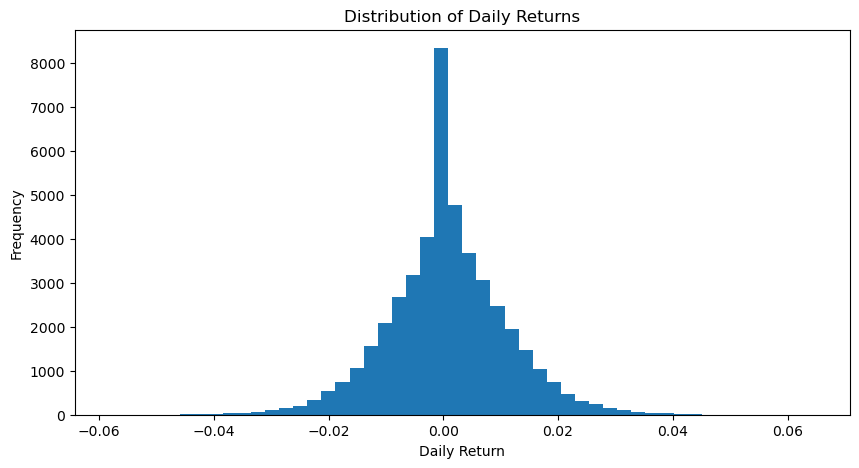

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(
    nav_history["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [30]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [31]:
print("Earliest Date :", nav_history["date"].min())
print("Latest Date   :", nav_history["date"].max())

Earliest Date : 2022-01-03 00:00:00
Latest Date   : 2026-05-29 00:00:00


---
# Section 5 : CAGR (1 Year, 3 Year, 5 Year)
---

In [32]:
# Latest NAV for each fund
latest_nav = (
    nav_history
    .groupby("amfi_code")
    .last()
    .reset_index()
)

latest_nav.head()

,amfi_code,date,nav,daily_return
0,100016,2026-05-29,583.6113,-0.012410
1,100025,2026-05-29,31.8843,-0.000809
2,100033,2026-05-29,342.0072,-0.004798
3,101206,2026-05-29,773.2939,-0.008529
4,101207,2026-05-29,53.9836,-0.014623


In [33]:
latest_date = nav_history["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [34]:
one_year_date = latest_date - pd.DateOffset(years=1)
three_year_date = latest_date - pd.DateOffset(years=3)
five_year_date = latest_date - pd.DateOffset(years=5)

print("1 Year :", one_year_date)
print("3 Year :", three_year_date)
print("5 Year :", five_year_date)

1 Year : 2025-05-29 00:00:00
3 Year : 2023-05-29 00:00:00
5 Year : 2021-05-29 00:00:00


In [38]:
nav_history[nav_history["date"] == one_year_date]

,amfi_code,date,nav,daily_return
888,100016,2025-05-29,596.8877,-0.002982
2038,100025,2025-05-29,30.7452,0.000700
3188,100033,2025-05-29,223.1951,0.006397
4338,101206,2025-05-29,522.7639,-0.007186
5488,101207,2025-05-29,71.0180,0.002711
6638,101208,2025-05-29,382.4272,0.000249
7788,102885,2025-05-29,156.2127,0.014817
8938,102886,2025-05-29,150.9137,-0.022312
10088,102887,2025-05-29,333.6461,0.003000
11238,118632,2025-05-29,82.5157,-0.008280


In [40]:
def get_nav_on_or_before(df, target_date):
    """
    Returns the latest available NAV on or before the target date
    for each mutual fund.
    """

    return (
        df[df["date"] <= target_date]
        .groupby("amfi_code")
        .last()
        .reset_index()[["amfi_code", "nav"]]
    )

In [41]:
one_year_nav = get_nav_on_or_before(nav_history, one_year_date)

one_year_nav.head()

,amfi_code,nav
0,100016,596.8877
1,100025,30.7452
2,100033,223.1951
3,101206,522.7639
4,101207,71.0180


In [42]:
five_year_nav = get_nav_on_or_before(nav_history, five_year_date)

five_year_nav.head()

,amfi_code,nav


In [44]:
three_year_nav = get_nav_on_or_before(
    nav_history,
    three_year_date
)

three_year_nav.head()

,amfi_code,nav
0,100016,561.5519
1,100025,28.4135
2,100033,147.2155
3,101206,360.4971
4,101207,61.3081


In [45]:
five_year_nav = get_nav_on_or_before(
    nav_history,
    five_year_date
)

five_year_nav.head()

,amfi_code,nav


In [46]:
print("1 Year Funds :", len(one_year_nav))
print("3 Year Funds :", len(three_year_nav))
print("5 Year Funds :", len(five_year_nav))

1 Year Funds : 40
3 Year Funds : 40
5 Year Funds : 0


In [47]:
# Rename NAV columns
latest_nav = latest_nav.rename(columns={"nav": "latest_nav"})
one_year_nav = one_year_nav.rename(columns={"nav": "nav_1yr"})
three_year_nav = three_year_nav.rename(columns={"nav": "nav_3yr"})

In [48]:
cagr_df = latest_nav.merge(
    one_year_nav,
    on="amfi_code",
    how="left"
)

cagr_df = cagr_df.merge(
    three_year_nav,
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,date,latest_nav,daily_return,nav_1yr,nav_3yr
0,100016,2026-05-29,583.6113,-0.012410,596.8877,561.5519
1,100025,2026-05-29,31.8843,-0.000809,30.7452,28.4135
2,100033,2026-05-29,342.0072,-0.004798,223.1951,147.2155
3,101206,2026-05-29,773.2939,-0.008529,522.7639,360.4971
4,101207,2026-05-29,53.9836,-0.014623,71.0180,61.3081


In [49]:
# CAGR for 1 year
cagr_df["cagr_1yr"] = (
    (cagr_df["latest_nav"] / cagr_df["nav_1yr"]) ** (1 / 1)
) - 1

# CAGR for 3 years
cagr_df["cagr_3yr"] = (
    (cagr_df["latest_nav"] / cagr_df["nav_3yr"]) ** (1 / 3)
) - 1

In [51]:
# Handle the 5-Year CAGR
cagr_df["cagr_5yr"] = np.nan

In [52]:
cagr_df["cagr_1yr"] = cagr_df["cagr_1yr"] * 100
cagr_df["cagr_3yr"] = cagr_df["cagr_3yr"] * 100

In [53]:
cagr_df[
    [
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
].head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-2.224271,1.292649,NaN
1,100025,3.704969,3.916390,NaN
2,100033,53.232396,32.442459,NaN
3,101206,47.924120,28.967695,NaN
4,101207,-23.986032,-4.152381,NaN


In [54]:
# Merge CAGR table with fund details
cagr_df = cagr_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [55]:
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

In [56]:
cagr_df["cagr_1yr"] = cagr_df["cagr_1yr"].round(2)
cagr_df["cagr_3yr"] = cagr_df["cagr_3yr"].round(2)

In [57]:
cagr_df.head()

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,-2.22,1.29,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,3.70,3.92,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,53.23,32.44,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,47.92,28.97,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,-23.99,-4.15,NaN


In [58]:
cagr_df = cagr_df.sort_values(
    by="cagr_3yr",
    ascending=False
)

In [59]:
cagr_df.head(10)

,amfi_code,scheme_name,fund_house,category,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,22.26,35.11,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,20.36,34.00,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,13.06,32.49,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,53.23,32.44,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,29.60,31.78,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,60.44,30.46,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,26.66,29.58,NaN
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,39.75,29.18,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,47.92,28.97,NaN
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,65.14,27.00,NaN


In [61]:
import os

os.makedirs("../outputs", exist_ok=True)

In [62]:
cagr_df.to_csv(
    "../outputs/cagr_comparison.csv",
    index=False
)

---
# Section 6 : Sharpe Ratio
---

In [63]:
# Annual risk-free rate (6.5%)
risk_free_rate = 0.065

# Convert to daily risk-free rate
daily_rf = risk_free_rate / 252

print("Annual RF :", risk_free_rate)
print("Daily RF  :", daily_rf)

Annual RF : 0.065
Daily RF  : 0.00025793650793650796


In [64]:
mean_returns = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .mean()
)

mean_returns.head()

amfi_code
100016    0.000142
100025    0.000170
100033    0.001080
101206    0.000852
101207    0.000424
Name: daily_return, dtype: float64

In [65]:
std_returns = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .std()
)

std_returns.head()

amfi_code
100016    0.009164
100025    0.002460
100033    0.011929
101206    0.009177
101207    0.016251
Name: daily_return, dtype: float64

In [66]:
sharpe_df = pd.DataFrame({
    "mean_return": mean_returns,
    "std_return": std_returns
}).reset_index()

sharpe_df.head()

,amfi_code,mean_return,std_return
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [75]:
# Calculate Sharpe Ratio
sharpe_df["sharpe_ratio"] = (
    (sharpe_df["mean_return"] - daily_rf)
    / sharpe_df["std_return"]
) * np.sqrt(252)

In [76]:
sharpe_df["sharpe_ratio"] = sharpe_df["sharpe_ratio"].round(3)

In [77]:
sharpe_df = sharpe_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [78]:
sharpe_df = sharpe_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "mean_return",
        "std_return",
        "sharpe_ratio"
    ]
]

In [79]:
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

In [80]:
sharpe_df.head(10)

,amfi_code,scheme_name,fund_house,category,mean_return,std_return,sharpe_ratio
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.001074,0.008941,1.448
1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.001082,0.010008,1.307
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.001124,0.011134,1.235
3,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.000917,0.008656,1.208
4,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.001161,0.012152,1.180
5,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.001055,0.011179,1.132
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.001080,0.011929,1.094
7,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.000865,0.008913,1.082
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.000852,0.009177,1.027
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.000843,0.009048,1.027


In [81]:
print(sharpe_df["sharpe_ratio"].describe())

count    40.000000
mean      0.537200
std       0.573738
min      -0.816000
25%       0.064750
50%       0.647000
75%       1.005250
max       1.448000
Name: sharpe_ratio, dtype: float64


In [82]:
# Keep only downside returns
downside_returns = nav_history.copy()

downside_returns["downside_return"] = downside_returns[
    "daily_return"
].where(
    downside_returns["daily_return"] < 0
)

In [83]:
downside_std = (
    downside_returns
    .groupby("amfi_code")["downside_return"]
    .std()
)

In [84]:
sortino_df = pd.DataFrame({
    "mean_return": mean_returns,
    "downside_std": downside_std
}).reset_index()

sortino_df.head()

,amfi_code,mean_return,downside_std
0,100016,0.000142,0.005261
1,100025,0.000170,0.001481
2,100033,0.001080,0.007133
3,101206,0.000852,0.005238
4,101207,0.000424,0.009555


In [85]:
# Calculate Sortino Ratio
sortino_df["sortino_ratio"] = (
    (sortino_df["mean_return"] - daily_rf)
    / sortino_df["downside_std"]
) * np.sqrt(252)

In [86]:
sortino_df["sortino_ratio"] = sortino_df["sortino_ratio"].round(3)

In [87]:
sortino_df = sortino_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [88]:
sortino_df = sortino_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "mean_return",
        "downside_std",
        "sortino_ratio"
    ]
]

In [89]:
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

In [90]:
sortino_df.head(10)

,amfi_code,scheme_name,fund_house,category,mean_return,downside_std,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.001074,0.005428,2.386
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.001082,0.005531,2.364
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.001124,0.006404,2.147
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.000917,0.004887,2.140
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.001161,0.007067,2.029
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.001055,0.006750,1.875
9,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,0.000865,0.005211,1.850
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.001080,0.007133,1.829
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.000843,0.005145,1.805
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,0.000852,0.005238,1.800


In [91]:
print(sortino_df["sortino_ratio"].describe())

count    40.000000
mean      0.923375
std       1.005401
min      -1.681000
25%       0.107000
50%       1.117000
75%       1.728000
max       2.386000
Name: sortino_ratio, dtype: float64


# Alpha and Beta Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [5]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [6]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [7]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [8]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

In [9]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna().reset_index(drop=True)

In [10]:
print("Total Funds :", nav_history["amfi_code"].nunique())
print("Benchmark Rows :", len(nifty100))

print("\nFund Date Range:")
print(nav_history["date"].min(), "to", nav_history["date"].max())

print("\nBenchmark Date Range:")
print(nifty100["date"].min(), "to", nifty100["date"].max())

Total Funds : 40
Benchmark Rows : 1149

Fund Date Range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Benchmark Date Range:
2022-01-04 00:00:00 to 2026-05-29 00:00:00


In [11]:
# Store Alpha & Beta results
alpha_beta = []

In [12]:
# Choose one fund
fund_code = nav_history["amfi_code"].unique()[0]

fund_df = nav_history[
    nav_history["amfi_code"] == fund_code
][["date", "daily_return"]].copy()

# Merge with benchmark returns
merged = pd.merge(
    fund_df,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

# Remove missing values
merged = merged.dropna()

print("Fund Code:", fund_code)
print("Rows after merge:", len(merged))

merged.head()

Fund Code: 100016
Rows after merge: 1149


,date,daily_return,benchmark_return
0,2022-01-04,-0.010306,-0.013540
1,2022-01-05,0.012865,0.004003
2,2022-01-06,-0.011377,-0.002935
3,2022-01-07,-0.001210,0.006150
4,2022-01-10,-0.008639,-0.008351


In [13]:
print(merged.dtypes)

date                datetime64[ns]
daily_return               float64
benchmark_return           float64
dtype: object


In [14]:
result = linregress(
    merged["benchmark_return"],
    merged["daily_return"]
)

print("Slope (Beta):", result.slope)
print("Intercept:", result.intercept)
print("Annual Alpha:", result.intercept * 252)
print("R²:", result.rvalue ** 2)

Slope (Beta): -0.058268431438808936
Intercept: 0.00014871352235886037
Annual Alpha: 0.03747580763443281
R²: 0.0026650326981333254


In [15]:
# Reset results
alpha_beta = []

for fund_code in nav_history["amfi_code"].unique():

    fund_df = nav_history.loc[
        nav_history["amfi_code"] == fund_code,
        ["date", "daily_return"]
    ].copy()

    merged = fund_df.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    # Skip if insufficient observations
    if len(merged) < 30:
        continue

    result = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund_code,
        "alpha": result.intercept * 252,
        "beta": result.slope,
        "r_squared": result.rvalue ** 2
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

print("Rows:", len(alpha_beta_df))
print("Unique Funds:", alpha_beta_df["amfi_code"].nunique())

alpha_beta_df.head()

Rows: 40
Unique Funds: 40


,amfi_code,alpha,beta,r_squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [19]:
# Round the Values
alpha_beta_df = alpha_beta_df.round({
    "alpha": 4,
    "beta": 4,
    "r_squared": 4
})

In [20]:
# Merge Fund Details
fund_master_unique = (
    fund_master
    .drop_duplicates(subset="amfi_code")
)

alpha_beta_df = alpha_beta_df.merge(
    fund_master_unique[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [24]:
print(alpha_beta_df.columns.tolist())

['amfi_code', 'alpha', 'beta', 'r_squared', 'scheme_name_x', 'fund_house_x', 'category_x', 'scheme_name_y', 'fund_house_y', 'category_y']


In [23]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [25]:
# Keep one copy of the columns
alpha_beta_df = alpha_beta_df.drop(
    columns=["scheme_name_y", "fund_house_y", "category_y"]
)

# Rename the remaining columns
alpha_beta_df = alpha_beta_df.rename(columns={
    "scheme_name_x": "scheme_name",
    "fund_house_x": "fund_house",
    "category_x": "category"
})

In [26]:
print(alpha_beta_df.columns.tolist())

['amfi_code', 'alpha', 'beta', 'r_squared', 'scheme_name', 'fund_house', 'category']


In [27]:
# Rearrange Columns
alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "alpha",
        "beta",
        "r_squared"
    ]
]

In [32]:
alpha_beta_df = alpha_beta_df.sort_values(
    by="alpha",
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,scheme_name,fund_house,category,alpha,beta,r_squared
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.3034,-0.0232,0.0001
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.3006,0.0115,0.0000
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2926,0.0005,0.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,0.2827,0.0181,0.0002
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2733,-0.0228,0.0003
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2720,0.0051,0.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.2698,0.0237,0.0005
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,0.2660,-0.0025,0.0000
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,0.2608,-0.0663,0.0019
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,0.2320,-0.0318,0.0009


In [33]:
import os

os.makedirs("../outputs", exist_ok=True)

alpha_beta_df.to_csv("../outputs/alpha_beta.csv", index=False)

In [34]:
alpha_beta_df.describe()

,amfi_code,alpha,beta,r_squared
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.159082,-0.001958,0.000605
std,14534.998667,0.087529,0.035203,0.000731
min,100016.000000,0.029000,-0.067000,0.000000
25%,118632.750000,0.068625,-0.023950,0.000075
50%,119551.500000,0.162300,-0.000050,0.000300
75%,120842.250000,0.221725,0.017050,0.001025
max,149324.000000,0.303400,0.103500,0.002800


# Maximum Drawdown

In [35]:
drawdown_results = []

In [36]:
# Select one fund
fund_code = nav_history["amfi_code"].unique()[0]

fund_df = (
    nav_history[nav_history["amfi_code"] == fund_code]
    .copy()
    .sort_values("date")
)

# Running Maximum NAV
fund_df["running_max"] = fund_df["nav"].cummax()

# Drawdown
fund_df["drawdown"] = (
    fund_df["nav"] / fund_df["running_max"]
) - 1

fund_df.head(10)

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574
5,100016,2022-01-10,510.7136,-0.008639,521.7239,-0.021104
6,100016,2022-01-11,513.5542,0.005562,521.7239,-0.015659
7,100016,2022-01-12,512.3195,-0.002404,521.7239,-0.018026
8,100016,2022-01-13,510.2445,-0.004050,521.7239,-0.022003
9,100016,2022-01-14,514.3636,0.008073,521.7239,-0.014108


In [37]:
# Maximum Drawdown value
max_dd = fund_df["drawdown"].min()

# Trough (worst point)
trough_idx = fund_df["drawdown"].idxmin()
trough_date = fund_df.loc[trough_idx, "date"]

# Peak (highest NAV before trough)
peak_idx = fund_df.loc[:trough_idx, "nav"].idxmax()
peak_date = fund_df.loc[peak_idx, "date"]

print("Maximum Drawdown :", round(max_dd * 100, 2), "%")
print("Peak Date        :", peak_date)
print("Trough Date      :", trough_date)

Maximum Drawdown : -24.73 %
Peak Date        : 2022-03-30 00:00:00
Trough Date      : 2022-09-15 00:00:00


In [38]:
# Store Maximum Drawdown results
drawdown_results = []

for fund_code in nav_history["amfi_code"].unique():

    fund_df = (
        nav_history[nav_history["amfi_code"] == fund_code]
        .copy()
        .sort_values("date")
    )

    # Running maximum NAV
    fund_df["running_max"] = fund_df["nav"].cummax()

    # Drawdown
    fund_df["drawdown"] = (
        fund_df["nav"] / fund_df["running_max"]
    ) - 1

    # Maximum Drawdown
    max_dd = fund_df["drawdown"].min()

    # Trough Date
    trough_idx = fund_df["drawdown"].idxmin()
    trough_date = fund_df.loc[trough_idx, "date"]

    # Peak Date (before trough)
    peak_idx = fund_df.loc[:trough_idx, "nav"].idxmax()
    peak_date = fund_df.loc[peak_idx, "date"]

    drawdown_results.append({
        "amfi_code": fund_code,
        "max_drawdown": max_dd,
        "peak_date": peak_date,
        "trough_date": trough_date
    })

max_drawdown_df = pd.DataFrame(drawdown_results)

In [44]:
# Merge Fund Details
max_drawdown_df = max_drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

In [48]:
print(max_drawdown_df.columns.tolist())

['amfi_code', 'scheme_name_x', 'fund_house_x', 'category_x', 'max_drawdown', 'peak_date', 'trough_date', 'scheme_name_y', 'fund_house_y', 'category_y']


In [49]:
# Remove duplicate columns created by the second merge
max_drawdown_df = max_drawdown_df.drop(
    columns=[
        "scheme_name_y",
        "fund_house_y",
        "category_y"
    ]
)

# Rename the remaining columns
max_drawdown_df = max_drawdown_df.rename(columns={
    "scheme_name_x": "scheme_name",
    "fund_house_x": "fund_house",
    "category_x": "category"
})

In [50]:
print(max_drawdown_df.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'max_drawdown', 'peak_date', 'trough_date']


In [52]:
# Arrange Columns
max_drawdown_df = max_drawdown_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "max_drawdown",
        "peak_date",
        "trough_date"
    ]
]

In [83]:
drawdown_results = []

for fund_code in nav_history["amfi_code"].unique():

    fund_df = (
        nav_history[nav_history["amfi_code"] == fund_code]
        .copy()
        .sort_values("date")
    )

    fund_df["running_max"] = fund_df["nav"].cummax()
    fund_df["drawdown"] = fund_df["nav"] / fund_df["running_max"] - 1

    trough_idx = fund_df["drawdown"].idxmin()
    max_dd = fund_df.loc[trough_idx, "drawdown"]

    peak_idx = fund_df.loc[:trough_idx, "nav"].idxmax()

    drawdown_results.append({
        "amfi_code": fund_code,
        "max_drawdown": round(max_dd * 100, 2),  # convert ONCE
        "peak_date": fund_df.loc[peak_idx, "date"],
        "trough_date": fund_df.loc[trough_idx, "date"]
    })

max_drawdown_df = pd.DataFrame(drawdown_results)

max_drawdown_df = max_drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name", "fund_house", "category"]
    ],
    on="amfi_code",
    how="left"
)

In [84]:
# Sort
max_drawdown_df = max_drawdown_df.sort_values(
    by="max_drawdown"
)

max_drawdown_df.head(10)

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name,fund_house,category
22,119599,-52.57,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
17,119095,-51.68,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity
4,101207,-35.45,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
39,149324,-31.17,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,119598,-28.71,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity
7,102886,-28.00,2025-01-07,2026-04-27,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
0,100016,-24.73,2022-03-30,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity
29,120842,-24.00,2023-11-09,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity
11,118634,-23.34,2025-04-09,2026-02-20,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity
15,119093,-21.75,2022-02-24,2023-05-22,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity


In [59]:
# Validation
print(len(max_drawdown_df))
print(max_drawdown_df["amfi_code"].nunique())

40
40


In [60]:
import os

os.makedirs("../outputs", exist_ok=True)

max_drawdown_df.to_csv(
    "../outputs/max_drawdown.csv",
    index=False
)

# Fund Scorecard

In [63]:
%who DataFrame

alpha_beta_df	 benchmark	 fund_df	 fund_master	 fund_master_unique	 max_drawdown_df	 merged	 nav_history	 nifty100	 
scorecard	 


In [64]:
import os

print(os.listdir("../outputs"))

['alpha_beta.csv', 'cagr_comparison.csv', 'max_drawdown.csv']


In [65]:
cagr_df = pd.read_csv("../outputs/cagr_comparison.csv")
alpha_beta_df = pd.read_csv("../outputs/alpha_beta.csv")
max_drawdown_df = pd.read_csv("../outputs/max_drawdown.csv")

In [66]:
rf = 0.065
daily_rf = rf / 252

sharpe_df = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std"
    )
    .reset_index()
)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["mean_return"] - daily_rf)
    / sharpe_df["std_return"]
) * np.sqrt(252)

sharpe_df["sharpe_ratio"] = sharpe_df["sharpe_ratio"].round(3)

In [67]:
sharpe_df.head()

,amfi_code,mean_return,std_return,sharpe_ratio
0,100016,0.000142,0.009164,-0.202
1,100025,0.000170,0.002460,-0.567
2,100033,0.001080,0.011929,1.094
3,101206,0.000852,0.009177,1.027
4,101207,0.000424,0.016251,0.163


### Code Of Fund Scorecard

In [116]:
max_drawdown_df.head()

,amfi_code,max_drawdown,peak_date,trough_date,scheme_name,fund_house,category
22,119599,-52.57,2023-01-17,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
17,119095,-51.68,2025-05-22,2026-05-11,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity
4,101207,-35.45,2024-11-21,2026-05-11,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
39,149324,-31.17,2024-05-03,2025-01-03,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,119598,-28.71,2024-08-28,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity


In [117]:
max_drawdown_df["max_drawdown"].head()

22   -52.57
17   -51.68
4    -35.45
39   -31.17
21   -28.71
Name: max_drawdown, dtype: float64

In [118]:
# Fresh scorecard
scorecard = fund_master[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "expense_ratio_pct"
    ]
].copy()

In [119]:
# Merge everything
scorecard = scorecard.merge(
    cagr_df[["amfi_code", "cagr_3yr"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code",
    how="left"
)

In [120]:
# Validate
print(scorecard.shape)
print(scorecard.columns.tolist())

(40, 9)
['amfi_code', 'scheme_name', 'fund_house', 'category', 'expense_ratio_pct', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'max_drawdown']


In [121]:
# Create the Ranks
# Higher is Better
scorecard["cagr_rank"] = scorecard["cagr_3yr"].rank(
    ascending=False, method="min"
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False, method="min"
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False, method="min"
)

# Lower expense ratio is better
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True, method="min"
)

# Less negative drawdown is better
scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False, method="min"
)

In [122]:
# Calculate the Weighted Score
scorecard["fund_score"] = (
    (41 - scorecard["cagr_rank"]) * 0.30 +
    (41 - scorecard["sharpe_rank"]) * 0.25 +
    (41 - scorecard["alpha_rank"]) * 0.20 +
    (41 - scorecard["expense_rank"]) * 0.15 +
    (41 - scorecard["drawdown_rank"]) * 0.10
)

scorecard["fund_score"] = (
    scorecard["fund_score"] / 40 * 100
).round(2)

In [123]:
# Overall Rank
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["overall_rank"] = scorecard.index + 1

In [124]:
# Final Output
scorecard[
    [
        "overall_rank",
        "scheme_name",
        "fund_score",
        "cagr_3yr",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct",
        "max_drawdown"
    ]
].head(10)

,overall_rank,scheme_name,fund_score,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown
0,1,Mirae Asset Large Cap Fund - Regular - Growth,86.25,34.00,1.448,0.2698,1.46,-11.27
1,2,ICICI Pru Midcap Fund - Regular - Growth,82.25,31.78,1.180,0.2926,1.36,-18.19
2,3,Kotak Flexicap Fund - Regular - Growth,82.00,29.58,1.307,0.2733,1.45,-12.97
3,4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,81.12,32.44,1.094,0.2720,1.38,-16.22
4,5,ICICI Pru Bluechip Fund - Direct - Growth,80.62,32.49,1.027,0.2119,0.80,-12.59
5,6,Axis Midcap Fund - Regular - Growth,77.38,35.11,0.998,0.2608,1.38,-20.96
6,7,SBI Bluechip Fund - Regular Plan - Growth,75.00,30.46,1.208,0.2320,1.54,-15.01
7,8,Mirae Asset Tax Saver Fund - Regular - Growth,73.87,29.18,1.235,0.2827,1.60,-16.40
8,9,ABSL Frontline Equity Fund - Regular - Growth,68.38,28.97,1.027,0.2140,1.60,-11.29
9,10,SBI Small Cap Fund - Regular Plan - Growth,67.38,26.67,0.945,0.3034,1.43,-28.71


In [125]:
scorecard.to_csv(
    "../outputs/fund_scorecard.csv",
    index=False
)

# Benchmark Comparison Chart

In [150]:
# Get Top 5 Funds
top5 = scorecard.head(5)

top5

,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,cagr_3yr,sharpe_ratio,alpha,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score,overall_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,1.46,34.00,1.448,0.2698,-11.27,2.0,1.0,7.0,23.0,8.0,86.25,1
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,1.36,31.78,1.180,0.2926,-18.19,5.0,5.0,3.0,15.0,25.0,82.25,2
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,1.45,29.58,1.307,0.2733,-12.97,7.0,2.0,5.0,22.0,13.0,82.00,3
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1.38,32.44,1.094,0.2720,-16.22,4.0,7.0,6.0,16.0,20.0,81.12,4
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.80,32.49,1.027,0.2119,-12.59,3.0,9.0,13.0,12.0,12.0,80.62,5


In [149]:
# Get Their AMFI Codes
top5_codes = top5["amfi_code"].tolist()

top5_codes

[148567, 120505, 120843, 100033, 120504]

In [148]:
# Filter NAV Data for Top 5 Funds
top5_nav = nav_history[
    nav_history["amfi_code"].isin(top5_codes)
].copy()

In [147]:
# Find the latest date
latest_date = nav_history["date"].max()

latest_date

Timestamp('2026-05-29 00:00:00')

In [146]:
# Now subtract 3 years:
start_date = latest_date - pd.DateOffset(years=3)

start_date

Timestamp('2023-05-29 00:00:00')

In [145]:
# Now filter
top5_nav = top5_nav[
    top5_nav["date"] >= start_date
]

In [144]:
# Normalize NAV
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [143]:
# Create two DataFrames
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [142]:
# Filter to the same 3-year period
nifty50 = nifty50[
    nifty50["date"] >= start_date
]

nifty100 = nifty100[
    nifty100["date"] >= start_date
]

In [141]:
# Normalize them
nifty50["normalized_index"] = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
    * 100
)

nifty100["normalized_index"] = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
    * 100
)

In [139]:
print(top5_nav.shape)

top5_nav.head()

(3925, 5)


,amfi_code,date,nav,daily_return,normalized_nav
2665,100033,2023-05-29,147.2155,0.004216,100.000000
2666,100033,2023-05-30,147.2007,-0.000101,99.989947
2667,100033,2023-05-31,147.4640,0.001789,100.168800
2668,100033,2023-06-01,146.5954,-0.005890,99.578781
2669,100033,2023-06-02,145.8015,-0.005416,99.039503


In [140]:
print(nifty50.shape)
print(nifty100.shape)

(785, 4)
(785, 4)


In [151]:
import matplotlib.pyplot as plt

In [153]:
print(top5_nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [154]:
top5_nav["normalized_nav"] = (
    top5_nav.groupby("amfi_code")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [155]:
top5_nav.head()

,amfi_code,date,nav,daily_return,normalized_nav
2300,100033,2022-01-03,107.3758,NaN,100.000000
2301,100033,2022-01-04,105.9447,-0.013328,98.667204
2302,100033,2022-01-05,105.4800,-0.004386,98.234425
2303,100033,2022-01-06,104.9350,-0.005167,97.726862
2304,100033,2022-01-07,104.3318,-0.005748,97.165097


In [157]:
print(nifty50.columns.tolist())
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value']
['date', 'index_name', 'close_value']


In [158]:
# Normalize NIFTY 50
nifty50["normalized_index"] = (
    nifty50["close_value"] / nifty50["close_value"].iloc[0]
) * 100

# Normalize NIFTY 100
nifty100["normalized_index"] = (
    nifty100["close_value"] / nifty100["close_value"].iloc[0]
) * 100

In [159]:
print(nifty50.head())
print(nifty100.head())

        date index_name  close_value  normalized_index
0 2022-01-03    NIFTY50     17492.79        100.000000
1 2022-01-04    NIFTY50     17689.64        101.125321
2 2022-01-05    NIFTY50     17835.05        101.956578
3 2022-01-06    NIFTY50     17878.51        102.205023
4 2022-01-07    NIFTY50     17759.15        101.522684
           date index_name  close_value  normalized_index
1150 2022-01-03   NIFTY100     17778.24        100.000000
1151 2022-01-04   NIFTY100     17537.52         98.645985
1152 2022-01-05   NIFTY100     17607.73         99.040906
1153 2022-01-06   NIFTY100     17556.05         98.750214
1154 2022-01-07   NIFTY100     17664.02         99.357529


In [160]:
print(top5_nav.columns)
print(nifty50.columns)
print(nifty100.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='object')
Index(['date', 'index_name', 'close_value', 'normalized_index'], dtype='object')
Index(['date', 'index_name', 'close_value', 'normalized_index'], dtype='object')


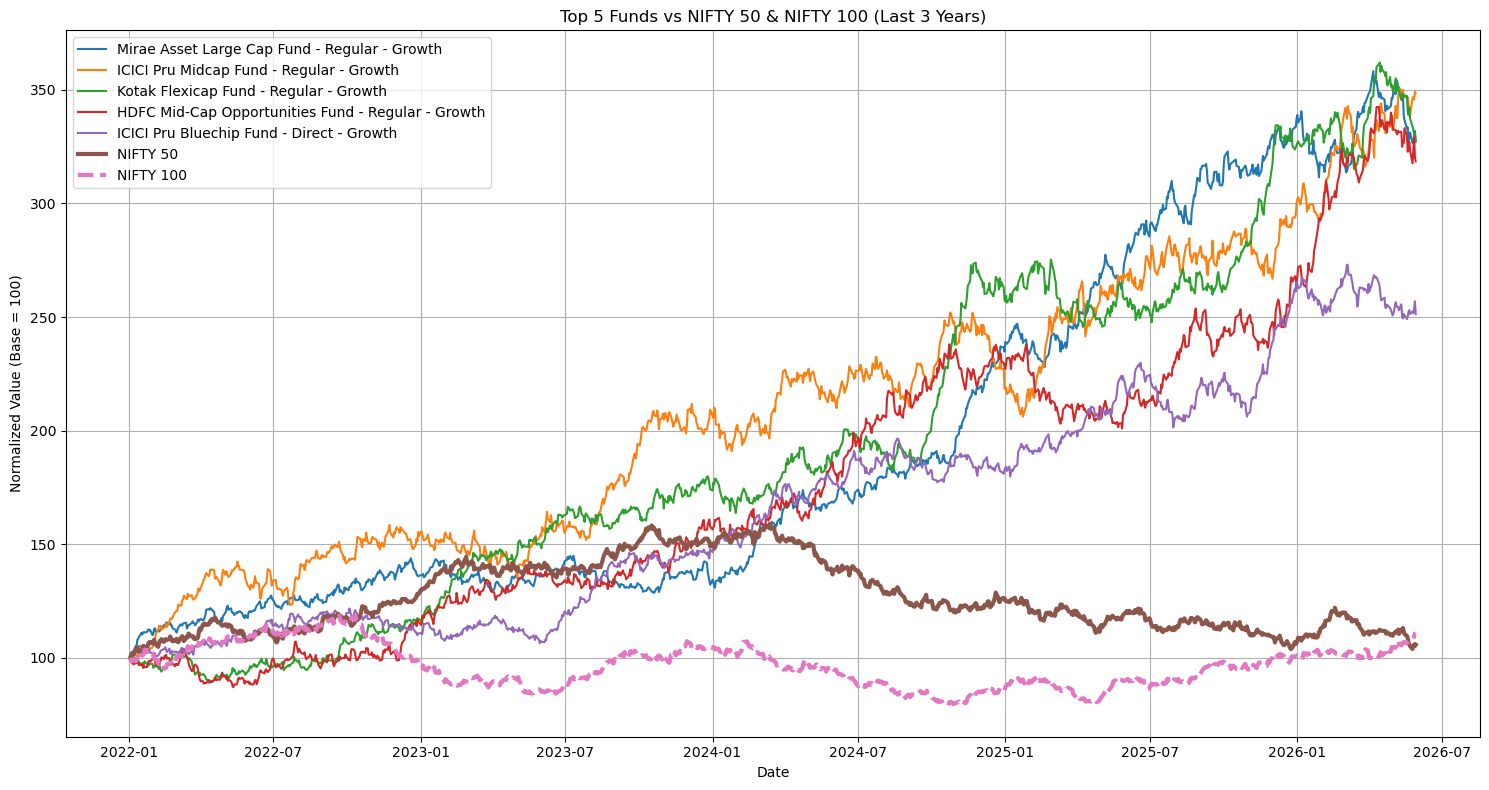

In [167]:
# Plot the Benchmark Comparison Chart and  Save the Figure
plt.figure(figsize=(15, 8))

# Plot Top 5 Funds
for code in top5_codes:
    
    fund = top5_nav[top5_nav["amfi_code"] == code]
    
    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == code,
        "scheme_name"
    ].values[0]
    
    plt.plot(
        fund["date"],
        fund["normalized_nav"],
        label=scheme_name
    )

# Plot NIFTY 50
plt.plot(
    nifty50["date"],
    nifty50["normalized_index"],
    linewidth=3,
    label="NIFTY 50"
)

# Plot NIFTY 100
plt.plot(
    nifty100["date"],
    nifty100["normalized_index"],
    linewidth=3,
    linestyle="--",
    label="NIFTY 100"
)

plt.title("Top 5 Funds vs NIFTY 50 & NIFTY 100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Compute tracking error

In [169]:
tracking_error = []

In [179]:
# Check the columns
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'normalized_index', 'benchmark_return']


In [180]:
# Recreate benchmark_return
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

In [181]:
# Verify
nifty100.head()

,date,index_name,close_value,normalized_index,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,100.000000,NaN
1151,2022-01-04,NIFTY100,17537.52,98.645985,-0.013540
1152,2022-01-05,NIFTY100,17607.73,99.040906,0.004003
1153,2022-01-06,NIFTY100,17556.05,98.750214,-0.002935
1154,2022-01-07,NIFTY100,17664.02,99.357529,0.006150


In [174]:
print(top5_nav.columns)
print(nifty50.columns)
print(nifty100.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return', 'normalized_nav'], dtype='object')
Index(['date', 'index_name', 'close_value', 'normalized_index'], dtype='object')
Index(['date', 'index_name', 'close_value', 'normalized_index',
       'benchmark_return'],
      dtype='object')


In [177]:
# Loop Through the Top 5 Funds
from numpy import sqrt

tracking_error = []

for code in top5_codes:

    fund = nav_history[
        nav_history["amfi_code"] == code
    ][["date", "daily_return"]].copy()

    merged = fund.merge(
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    te = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * sqrt(252)
    )

    tracking_error.append({
        "amfi_code": code,
        "tracking_error": round(te, 4)
    })

In [178]:
# Create DataFrame
tracking_error_df = pd.DataFrame(tracking_error)

In [182]:
# Add Fund Information
tracking_error_df = tracking_error_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)

In [184]:
# Arrange Columns
tracking_error_df = tracking_error_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "tracking_error"
    ]
]

In [185]:
# Sort
tracking_error_df = tracking_error_df.sort_values(
    "tracking_error"
)

In [187]:
# Display Results
tracking_error_df

,amfi_code,scheme_name,fund_house,category,tracking_error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,0.1897
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,0.1916
2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,0.2064
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,0.2287
1,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,0.2320


In [188]:
# Save
tracking_error_df.to_csv(
    "../outputs/tracking_error.csv",
    index=False
)